# Credit Card Fraud Detection using Autoencoder

This notebook implements an autoencoder neural network for detecting anomalies (fraud) in credit card transactions.

## 1. Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

/Users/prathameshkale/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Load and Preprocess Dataset

In [3]:

df = pd.read_csv('creditcard.csv')

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print data shapes
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (227845, 30)
Testing data shape: (56962, 30)


## 3. Build the Autoencoder Model

In [4]:
# Define input dimension
input_dim = X_train.shape[1]

# Build the encoder
encoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(4, activation='relu')  # Latent space dimension
])

# Build the decoder
decoder = models.Sequential([
    layers.Dense(8, activation='relu', input_shape=(4,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

# Build the autoencoder
autoencoder = models.Sequential([encoder, decoder])

# Print model summaries
print("Encoder Summary:")
encoder.summary()
print("\nDecoder Summary:")
decoder.summary()
print("\nAutoencoder Summary:")
autoencoder.summary()

Encoder Summary:


/Users/prathameshkale/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668 (2.61 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 4)              │           668 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 30)             │           694 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,362 (5.32 KB)

 Trainable params: 1,362 (5.32 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Compile and Train the Model

In [8]:
# Compile the model
autoencoder.compile(optimizer='adam', 
                   loss='mse',
                   metrics=['mae'])

# Train the model
history = autoencoder.fit(X_train_scaled, X_train_scaled,
                         epochs=50,
                         batch_size=32,
                         validation_split=0.2,
                         verbose=1)



Epoch 1/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 0.4859 - mae: 0.4642 - val_loss: 0.4971 - val_mae: 0.4689
Epoch 2/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.4899 - mae: 0.4651 - val_loss: 0.4912 - val_mae: 0.4660
Epoch 3/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.4807 - mae: 0.4637 - val_loss: 0.4911 - val_mae: 0.4661
Epoch 4/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.4822 - mae: 0.4636 - val_loss: 0.4903 - val_mae: 0.4652
Epoch 5/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.4828 - mae: 0.4634 - val_loss: 0.4936 - val_mae: 0.4674
Epoch 6/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.4796 - mae: 0.4632 - val_loss: 0.4876 - val_mae: 0.4638
Epoch 7/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.4807 - mae: 0.4633 - val_loss: 0.4896 - val_mae: 0.4655
Epoch 8/50
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.4783 - mae: 0.4628 - val_loss: 0.4877 - val_mae: 0.4639
Epoch 9/50
5697/5697 ━━━━━━━━━━━━━━━━━━━

## 5. Evaluate and Detect Anomalies

7121/7121 ━━━━━━━━━━━━━━━━━━━━ 1s 176us/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 174us/step
1.0895247249570912
[1 0 0 ... 0 0 1]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56864
           1       0.03      0.78      0.05        98

    accuracy                           0.95     56962
   macro avg       0.51      0.86      0.51     56962
weighted avg       1.00      0.95      0.97     56962



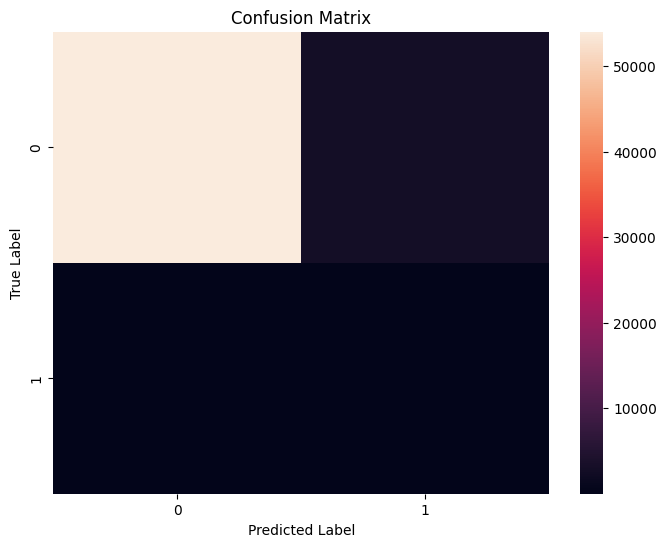

In [13]:
train_predictions = autoencoder.predict(X_train_scaled)
mse = np.mean(np.power(X_train_scaled - train_predictions, 2), axis=1)


# Get reconstruction error on test data
test_predictions = autoencoder.predict(X_test_scaled)
test_mse = np.mean(np.power(X_test_scaled - test_predictions, 2), axis=1)

# Find threshold for anomaly detection (e.g., 95th percentile of normal transactions)
threshold = np.percentile(mse[y_train == 0], 95)
print(threshold)
# Predict anomalies
predictions = (test_mse > threshold).astype(int)
print(predictions)
# Calculate metrics
from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()